In [4]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")

# path ke direktori data (tanpa import dari package src)
RAW_DIR = Path("../data/raw")
INTERIM_DIR = Path("../data/interim")
MERGED_TRAIN_PATH = INTERIM_DIR / "train_merged.parquet"

# 01 - Memuat Data & Overview

## Pernyataan Masalah

### Konteks Bisnis
IEEE-CIS Fraud Detection dataset (Kaggle competition) — deteksi transaksi e-commerce fraud. Data disediakan oleh Vesta Corporation.

### Objective
Prediksi probabilitas transaksi adalah fraud (`isFraud`) berdasarkan transaction attributes dan identity signals.

- Input: kolom transaksi (amount, product, card, device, dll.)
- Output: probabilitas fraud (0.0-1.0)
- Tipe tugas: binary classification
- Metrik utama: ROC-AUC

### Tantangan Utama
1. Class imbalance: ~3.5% fraud rate
2. High dimensionality: 400+ fitur
3. Missingness: cakupan tabel identity sekitar ~25%
4. Anonymous engineered features: `V1`-`V339` tidak memiliki deskripsi publik
5. Kolom waktu: `TransactionDT` adalah detik dari titik referensi (bukan timestamp sebenarnya)

### Kriteria Sukses
- ROC-AUC > 0.91

## Tujuan Notebook
- Memahami struktur dataset dan kelompok kolom utama
- Memuat data secara efisien (Parquet)
- Melakukan sanity check tingkat tinggi (skema, statistik dasar, missingness)
- Membuat dan menyimpan tabel training yang digabungkan untuk notebook selanjutnya

## File Dataset
- `train_transaction.parquet` (~590K baris)
- `train_identity.parquet` (~144K baris; cakupan ~25%)
- `test_transaction.parquet`
- `test_identity.parquet`

Target:
- `isFraud` = 1 untuk transaksi fraud

## LOAD DATASET

In [ ]:
# load data transaksi

train_trans = pd.read_parquet(RAW_DIR / 'train_transaction.parquet')

print(f'Transaction data loaded: {train_trans.shape}')

Transaction data loaded: (590540, 394)


In [ ]:
# load  identitas

train_ident = pd.read_parquet(RAW_DIR / 'train_identity.parquet')

print(f'Identity data loaded: {train_ident.shape}')

Identity data loaded: (144233, 41)


In [7]:
# cek penggunaan memori 
def get_memory(df):
    """Calculate memory usage of a dataframe in MB."""
    return df.memory_usage(deep=True).sum() / 1024**2

trans_mem = get_memory(train_trans)
ident_mem = get_memory(train_ident)

print("memory usage : ")
print(f"Transaction : {trans_mem:.1f} MB")
print(f"Identity : {ident_mem:.1f}MB")
print(f"Total : {trans_mem + ident_mem:.1f}MB")

memory usage : 
Transaction : 861.1 MB
Identity : 16.0MB
Total : 877.1MB


### Data Integrity

In [ ]:
# cek kualitas data

dup_ids = train_trans['TransactionID'].duplicated().sum()
print(f"Duplicate TransactionID: {dup_ids}")

print(f"Transaction columns: {len(train_trans.columns)}")
print(f"Identity columns:   {len(train_ident.columns)}")

all_null = train_trans.columns[train_trans.isnull().all()].tolist()
print(f"All-null columns in transaction: {len(all_null)}")
all_null_ident = train_ident.columns[train_ident.isnull().all()].tolist()
print(f"All-null columns in identity: {len(all_null_ident)}")

Duplicate TransactionID: 0
Transaction columns: 394 (expected 394)
Identity columns:   41 (expected 41)
All-null columns in transaction: 0
All-null columns in identity: 0


## DATA OVERVIEW

In [ ]:
# sample data transaksi
train_trans.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Fraud Transaction Preview

Mari kita lihat sekilas beberapa transaksi fraud untuk memahami polanya.

In [ ]:
# contoh transaksi fraud
fraud_trans = train_trans[train_trans['isFraud'] == 1]
print(f"Fraud transactions: {len(fraud_trans):,} ({len(fraud_trans)/len(train_trans)*100:.2f}% of total)\n")
fraud_trans.head(10)

Fraud transactions: 20,663 (3.50% of total)



,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
203,2987203,1,89760,445.000000,W,18268,583.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
240,2987240,1,90193,37.098000,C,13413,103.0,185.0,visa,137.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243,2987243,1,90246,37.098000,C,13413,103.0,185.0,visa,137.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
245,2987245,1,90295,37.098000,C,13413,103.0,185.0,visa,137.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
288,2987288,1,90986,155.520996,C,16578,545.0,185.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
367,2987367,1,92350,225.000000,R,4425,562.0,150.0,mastercard,197.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
405,2987405,1,92999,90.570000,C,4504,500.0,185.0,mastercard,219.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
630,2987630,1,97843,12.326000,C,5812,408.0,185.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
683,2987683,1,99584,124.344002,C,5812,408.0,185.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
736,2987736,1,100591,100.000000,W,15063,NaN,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# grouping berdasar tipe fitur

columns = train_trans.columns.tolist()

# group mapping
col_groups = {
    'Target & ID' : ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt'],
    'Product' : [c for c in columns if c.startswith('ProductCD')],
    'Card' : [c for c in columns if c.startswith('card')],
    'Address' : ['addr1', 'addr2', 'dist1', 'dist2'],
    'Email' : [c for c in columns if 'email' in c.lower()],
    'Count' : [c for c in columns if c.startswith('C') and c[1:].isdigit()],
    'TimeDelta' : [c for c in columns if c.startswith('D') and c[1:].isdigit()],
    'Match' : [c for c in columns if c.startswith('M') and c[1:].isdigit()],
    'Vesta' : [c for c in columns if c.startswith('V') and c[1:].isdigit()]    
}

print("Columns groups:")
for group, cols in col_groups.items():
    print(f'   {group}: {len(cols)} columns')

Columns groups:
   Target & ID: 4 columns
   Product: 1 columns
   Card: 6 columns
   Address: 4 columns
   Email: 2 columns
   Count: 14 columns
   TimeDelta: 15 columns
   Match: 9 columns
   Vesta: 339 columns


Target Distribution
Not fraud (0) : 569,877 (96.50%)
Fraud (1)     : 20,663 (3.50%)


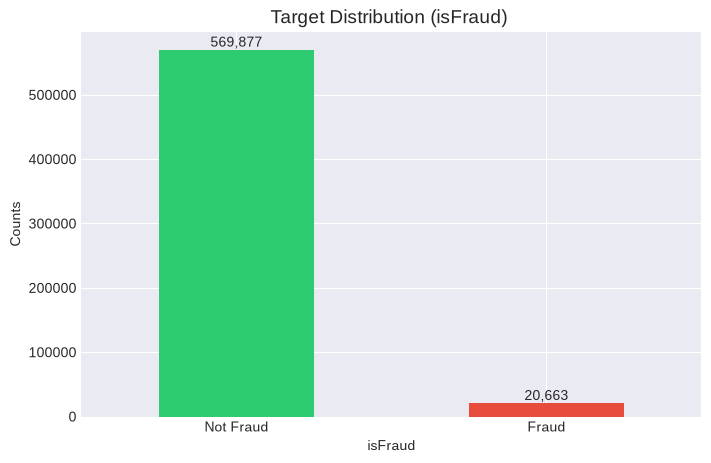

In [12]:
# distribusi target

fraud_counts = train_trans['isFraud'].value_counts()
fraud_pct = train_trans['isFraud'].mean() * 100

print('Target Distribution')
print(f'Not fraud (0) : {fraud_counts[0]:,} ({100 - fraud_pct:.2f}%)')
print(f'Fraud (1)     : {fraud_counts[1]:,} ({fraud_pct:.2f}%)')

# visualisasi
fig, ax = plt.subplots(figsize=(8,5))
colors = ['#2ecc71', '#e74c3c']
fraud_counts.plot(kind='bar', color=colors, ax=ax)
ax.set_title('Target Distribution (isFraud) ', fontsize=14)
ax.set_xlabel('isFraud')
ax.set_ylabel('Counts')
ax.set_xticklabels(['Not Fraud', 'Fraud'], rotation=0)

for i, v in enumerate(fraud_counts):
    ax.text(i, v + 5000, f'{v:,}', ha='center')

In [ ]:
dtype_counts = train_trans.dtypes.value_counts()

print('Data types : ')
for dtype, count in dtype_counts.items():
    print(f'{dtype} : {count} columns')

Data types : 
float32 : 376 columns
category : 8 columns
int32 : 2 columns
int8 : 1 columns
category : 1 columns
int16 : 1 columns
category : 1 columns
category : 1 columns
category : 1 columns
category : 1 columns
category : 1 columns


## IDENTITY DATA

In [14]:
train_ident.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


## MERGE TRANSACTION & IDENTITY

In [15]:
trans_ids = set(train_trans['TransactionID'])
ident_ids = set(train_ident['TransactionID'])

matching = trans_ids & ident_ids
trans_only = trans_ids - ident_ids

coverage = len(matching) / len(trans_ids) * 100

print('merge analysis :')
print(f'transaction : {len(trans_ids):,}')
print(f'Identities : {len(ident_ids):,}')
print(f'Matching: {len(matching):,} ({coverage:.1f}%)')
print(f'Trans w/o ID : {len(trans_only):,}')

merge analysis :
transaction : 590,540
Identities : 144,233
Matching: 144,233 (24.4%)
Trans w/o ID : 446,307


In [ ]:
# merged tabel transaksi dan identitas
train = pd.merge(
    train_trans,
    train_ident,
    on='TransactionID',
    how='left'
)

print(f'Merge Data : {train.shape[0]:,} rows x {train.shape[1]:,} columns')
print(f"Memory : {get_memory(train):.1f} MB")

Merge Data : 590,540 rows x 434 columns
Memory : 924.2 MB


## MISSING VALUE

In [ ]:
missing = train.isnull().sum()
missing_pct = (missing / len(train)* 100).sort_values(ascending=False)

cols_with_missing = missing_pct[missing_pct > 0]

print(f'Missing Value')
print(f'Column with missing : {len(cols_with_missing)} / {len(train.columns)}')
print(missing_pct.head(10).to_string())

Missing Value
Column with missing : 414 / 434
id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
id_26    99.125715
id_27    99.124699
id_23    99.124699
id_22    99.124699
dist2    93.628374


Missing Value Categories:
>75% Missing : 208 columns
10-50% Missing : 108 columns
<10% Missing : 92 columns
No Missing : 20 columns
50-75% Missing : 6 columns


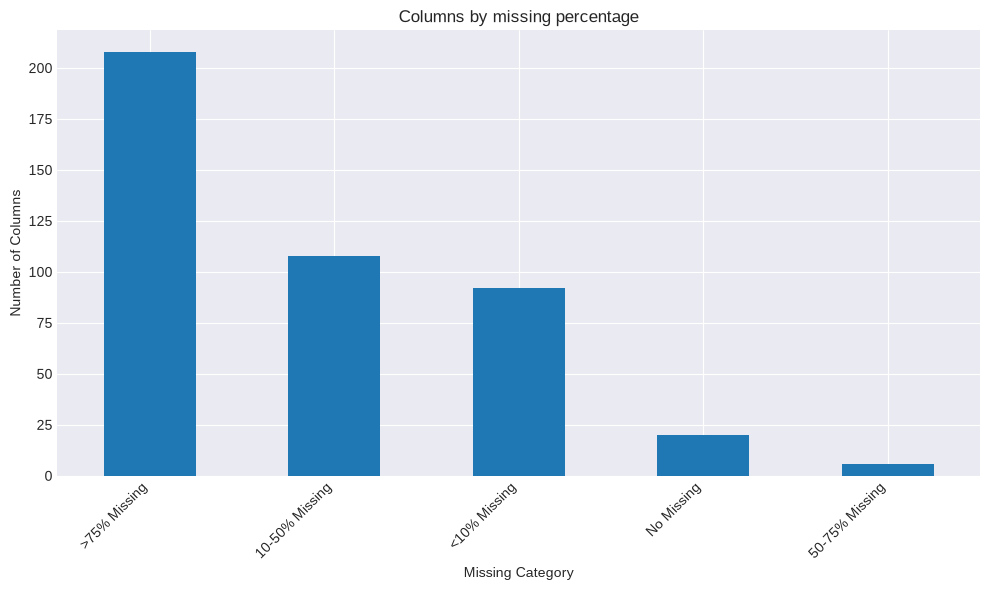

In [ ]:
# visualisasi sebaran missing value

def categorize_missing(pct):
    if pct == 0:
        return "No Missing"
    if pct < 10:
        return "<10% Missing"
    if pct < 50:
        return "10-50% Missing"
    if pct < 75:
        return "50-75% Missing"
    return ">75% Missing"

missing_categories = missing_pct.apply(categorize_missing).value_counts()

print('Missing Value Categories:')
for cat, count in missing_categories.items():
    print(f'{cat} : {count} columns')

# visualisasi
fig, ax = plt.subplots(figsize=(10,6))
missing_categories.plot(kind='bar', ax=ax)
ax.set_title('Columns by missing percentage')
ax.set_xlabel('Missing Category')
ax.set_ylabel('Number of Columns')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## OVERVIEW FITUR

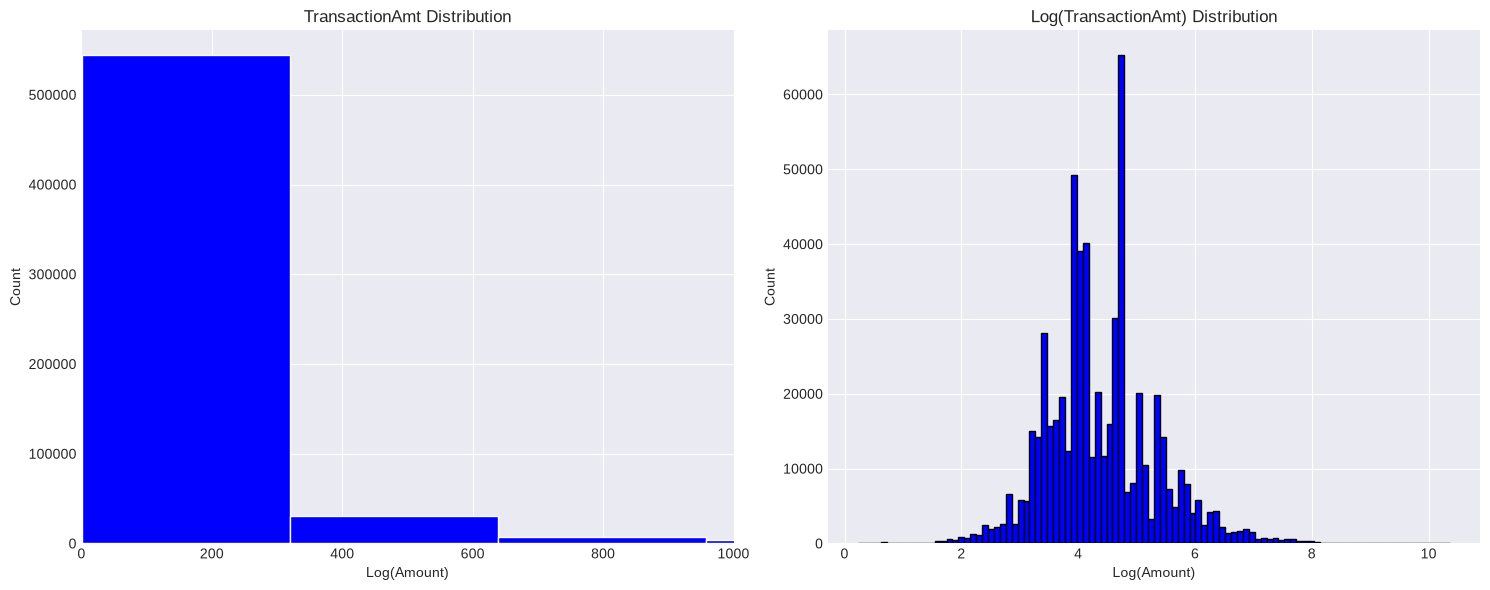

In [ ]:
# distribusi jumlah transaksi
train['TransactionAmt'].describe().round(2)

# visualisasi
fig, axes = plt.subplots(1, 2,figsize=(15,6))

axes[0].hist(train['TransactionAmt'], bins=100, color='blue', edgecolor ='white')
axes[0].set_title('TransactionAmt Distribution')
axes[0].set_xlabel('Log(Amount)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0,1000)

# distribusi setelah log-transform
axes[1].hist(np.log1p(train['TransactionAmt']), bins=100, color='blue', edgecolor='black')
axes[1].set_title('Log(TransactionAmt) Distribution')
axes[1].set_xlabel('Log(Amount)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

            count        mean         std    min        25%   50%    75%  \
isFraud                                                                    
0        569877.0  134.511658  239.395081  0.251  43.970001  68.5  120.0   
1         20663.0  149.244766  232.212158  0.292  35.043999  75.0  161.0   

                  max  
isFraud                
0        31937.390625  
1         5191.000000  


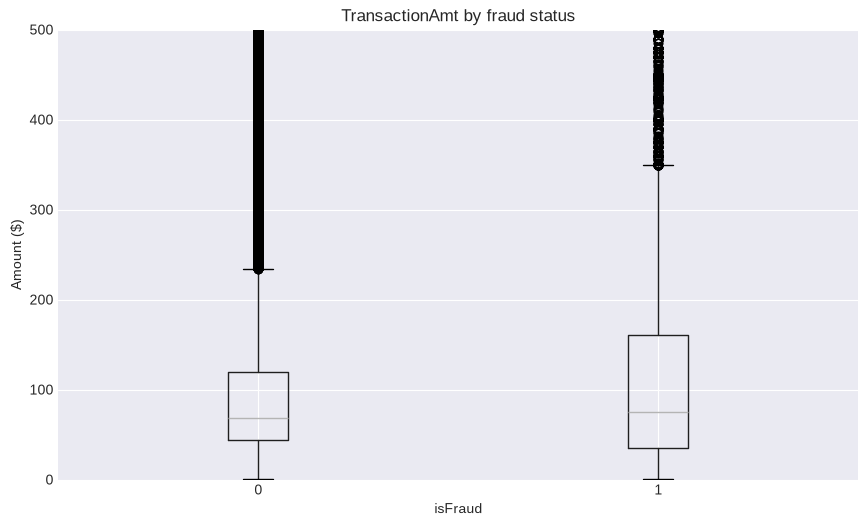

In [ ]:
# perbandingan jumlah transaksi fraud dan non-fraud

fraud_amt = train.groupby('isFraud')['TransactionAmt'].describe()
print(fraud_amt)

# visualisasi
fig, ax = plt.subplots(figsize=(10,6))
train.boxplot(column='TransactionAmt', by='isFraud', ax=ax)
ax.set_title('TransactionAmt by fraud status')
ax.set_xlabel('isFraud')
ax.set_ylabel('Amount ($)')
ax.set_ylim(0,500)
plt.suptitle('')
plt.show()

ProductCD Distribution:
ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64

Fraud Rate by ProductCD:
ProductCD
C    0.116873
H    0.047662
R    0.037826
S    0.058996
W    0.020399
Name: isFraud, dtype: float64


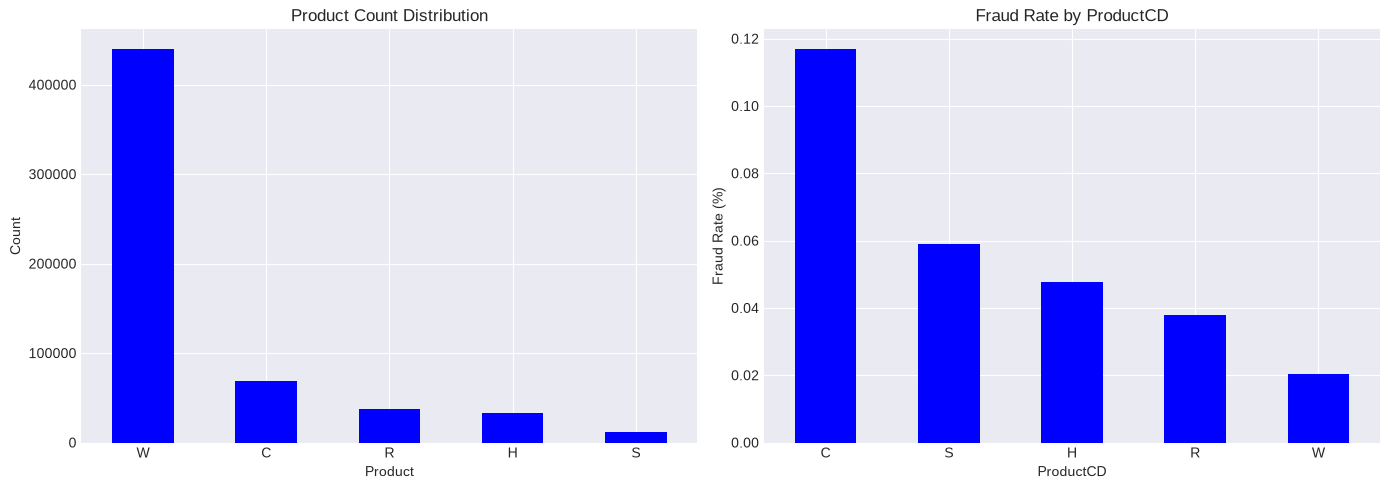

In [21]:
# distribusi kategori produk

product_counts = train['ProductCD'].value_counts()
product_fraud = train.groupby('ProductCD')['isFraud'].mean()

print('ProductCD Distribution:')
print(product_counts)
print('\nFraud Rate by ProductCD:')
print(product_fraud)


# visualisasi
fig, axes = plt.subplots(1,2,figsize=(14,5))

# jumlah per produk
product_counts.plot(kind='bar', color='blue', ax=axes[0])
axes[0].set_title('Product Count Distribution')
axes[0].set_xlabel('Product')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# fraud rate per produk
product_fraud.sort_values(ascending=False).plot(kind='bar', color='blue', ax=axes[1])
axes[1].set_title('Fraud Rate by ProductCD')
axes[1].set_xlabel('ProductCD')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# simpan data 

MERGED_TRAIN_PATH.parent.mkdir(parents=True, exist_ok=True)
train.to_parquet(MERGED_TRAIN_PATH, engine="pyarrow", compression="snappy")
print(f'Saved merged data: {MERGED_TRAIN_PATH}')
print(f'Final shape: {train.shape}')

Saved merged data: ../data/interim/train_merged.parquet
Final shape: (590540, 434)
